# Module 2

## Sampling and Estimation

- Random sample  
- Sampling distribution  
- Central Limit Theorem (CLT)  
- Point estimate  
- Margin of error  
- Confidence interval estimate  
- Necessary sample size

## Setup and Synthetic Population
We'll import common libraries and generate a synthetic **finite population** to sample from.
- We'll treat **scores** as our population variable (integers 0–100).  
- We'll mark a **success** as `score ≥ 70` for proportion examples.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

plt.style.use('seaborn-v0_8-whitegrid')

# Try to import SciPy (optional); if unavailable we will use robust fallbacks
try:
    import scipy.stats as st
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Reproducibility
rng = np.random.default_rng(seed=123)

# Build a synthetic population of size N
N = 20000
# Mix of distributions for realism: normal core + a small skewed tail
core = rng.normal(loc=72, scale=12, size=int(N*0.9))
tail = rng.exponential(scale=15, size=int(N*0.1)) + 60
pop_scores = np.clip(np.concatenate([core, tail]).round(), 0, 100).astype(int)

population = pd.DataFrame({
    'score': pop_scores
})
population['success'] = (population['score'] >= 70).astype(int)

population.head()

,score,success
0,60,0
1,68,0
2,87,1
3,74,1
4,83,1


## Random Sample
A **simple random sample (SRS)** of size *n* selects items from the population **without replacement**, each sample of size *n* equally likely.

Below we draw an SRS and compute basic summaries.


Sample size n = 100
Sample mean score = 71.60
Sample proportion success (score ≥ 70) = 0.500


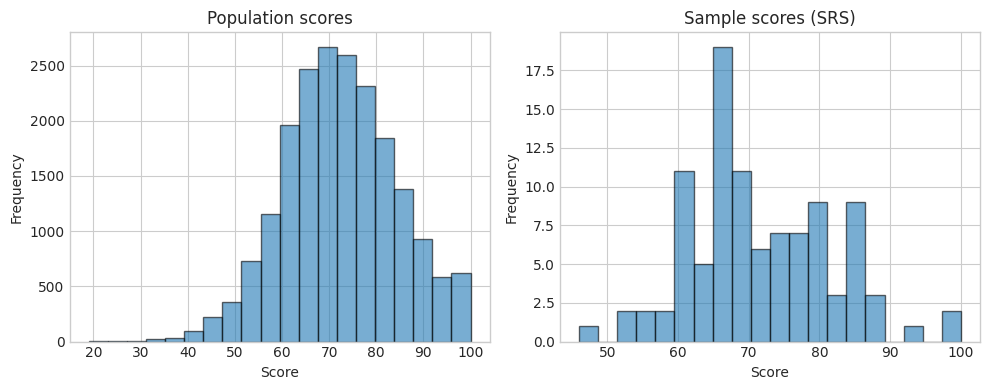

In [2]:
def simple_random_sample(df, n, rng):
    idx = rng.choice(df.index.to_numpy(), size=n, replace=False)
    return df.loc[idx].reset_index(drop=True)

n = 100
sample = simple_random_sample(population, n=n, rng=rng)

print(f"Sample size n = {len(sample)}")
print(f"Sample mean score = {sample['score'].mean():.2f}")
print(f"Sample proportion success (score ≥ 70) = {sample['success'].mean():.3f}")

# Visualize sample vs. population
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].hist(population['score'], bins=20, edgecolor='black', alpha=0.6)
ax[0].set_title('Population scores')
ax[0].set_xlabel('Score'); ax[0].set_ylabel('Frequency')

ax[1].hist(sample['score'], bins=20, edgecolor='black', alpha=0.6)
ax[1].set_title('Sample scores (SRS)')
ax[1].set_xlabel('Score'); ax[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

## Sampling Distribution
The **sampling distribution** of a statistic (e.g., sample mean \(\bar{X}\) or sample proportion \(\hat{p}\)) is the distribution of that statistic over **many repeated samples** from the population.

We empirically approximate these distributions by repeated sampling.


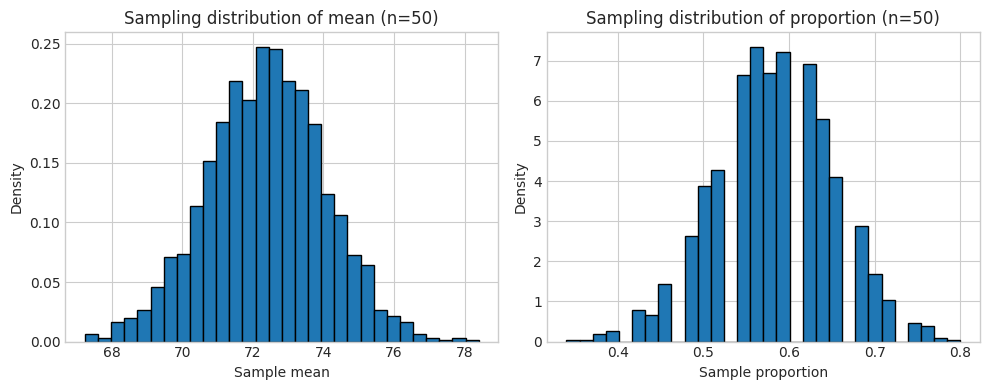

Mean of sample means ≈ 72.36
SD of sample means (empirical) ≈ 1.66
Mean of sample proportions ≈ 0.582
SD of sample proportions (empirical) ≈ 0.070


In [3]:
def repeated_srs_stats(df, n, B=2000, rng=None):
    rng = rng or np.random.default_rng()
    means = []
    props = []
    for _ in range(B):
        s = df.sample(n=n, replace=False, random_state=None)
        means.append(s['score'].mean())
        props.append(s['success'].mean())
    return np.array(means), np.array(props)

n = 50
B = 2000
means, props = repeated_srs_stats(population, n=n, B=B, rng=rng)

# Visualize sampling distributions
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].hist(means, bins=30, density=True, edgecolor='black')
ax[0].set_title(f'Sampling distribution of mean (n={n})')
ax[0].set_xlabel('Sample mean'); ax[0].set_ylabel('Density')

ax[1].hist(props, bins=30, density=True, edgecolor='black')
ax[1].set_title(f'Sampling distribution of proportion (n={n})')
ax[1].set_xlabel('Sample proportion'); ax[1].set_ylabel('Density')
plt.tight_layout(); plt.show()

print(f"Mean of sample means ≈ {means.mean():.2f}")
print(f"SD of sample means (empirical) ≈ {means.std(ddof=1):.2f}")
print(f"Mean of sample proportions ≈ {props.mean():.3f}")
print(f"SD of sample proportions (empirical) ≈ {props.std(ddof=1):.3f}")

## Central Limit Theorem (CLT)
The CLT says that, for i.i.d. samples with finite variance, the sampling distribution of the **sample mean** tends toward **Normal** as \(n\) grows, 
regardless of the population's shape. We illustrate using a **skewed** population (Exponential).


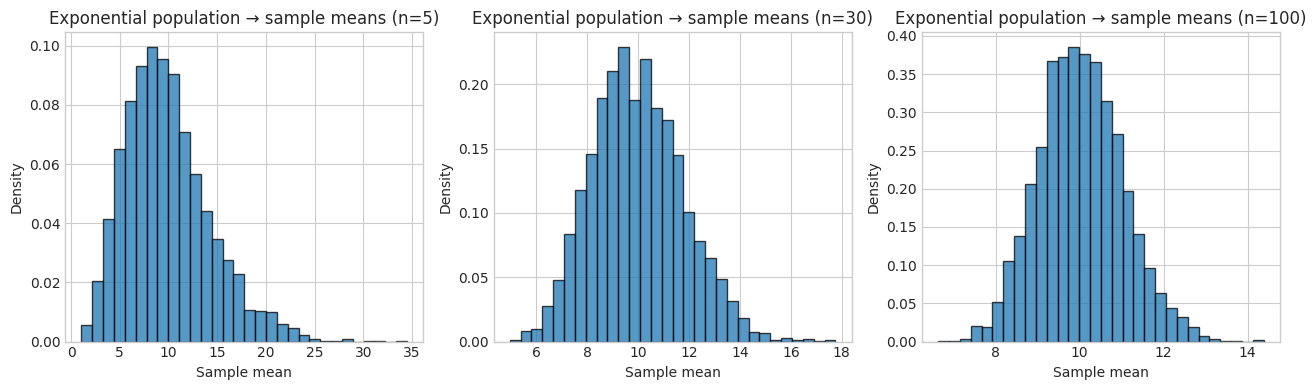

In [4]:
# CLT demo using exponential population
lam = 1/10  # rate
size = 50000
exp_population = rng.exponential(scale=1/lam, size=size)

# Function to collect sample means for different n
ns = [5, 30, 100]
B = 3000
means_by_n = {}
for n in ns:
    m = []
    for _ in range(B):
        s = rng.choice(exp_population, size=n, replace=False)
        m.append(np.mean(s))
    means_by_n[n] = np.array(m)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(13,4))
for i, n in enumerate(ns):
    ax[i].hist(means_by_n[n], bins=30, density=True, edgecolor='black', alpha=0.75)
    ax[i].set_title(f'Exponential population → sample means (n={n})')
    ax[i].set_xlabel('Sample mean'); ax[i].set_ylabel('Density')
plt.tight_layout(); plt.show()

## Point Estimates
Common point estimators:
- **Mean**: \(\hat{\mu} = \bar{X}\)
- **Proportion**: \(\hat{p} = x/n\)
- **Variance** (sample): \(s^2\)


In [5]:
# Compute point estimates from our sample
xbar = sample['score'].mean()
p_hat = sample['success'].mean()
s2 = sample['score'].var(ddof=1)
s = sample['score'].std(ddof=1)

print(f"Point estimate of mean (x̄): {xbar:.2f}")
print(f"Point estimate of proportion (p̂): {p_hat:.3f}")
print(f"Sample variance (s²): {s2:.2f} | Sample std dev (s): {s:.2f}")

Point estimate of mean (x̄): 71.60
Point estimate of proportion (p̂): 0.500
Sample variance (s²): 102.93 | Sample std dev (s): 10.15


## Margin of Error (ME)
For a confidence level \(1-\alpha\), the **margin of error** depends on the standard error and the critical value.

- Mean with **known** \(\sigma\): \(\text{ME} = z^* \tfrac{\sigma}{\sqrt{n}}\)
- Mean with **unknown** \(\sigma\): \(\text{ME} = t^* \tfrac{s}{\sqrt{n}}\)
- Proportion: \(\text{ME} = z^* \sqrt{\tfrac{\hat{p}(1-\hat{p})}{n}}\)

We'll implement robust helpers for **z^*** (normal) and **t^*** (Student) critical values.


In [6]:
# Normal CDF via error function
# Phi(x) = 0.5 * [1 + erf(x / sqrt(2))]

def normal_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

# Invert normal CDF numerically (bisection) for robustness without SciPy
def z_star(conf_level):
    target = 0.5 * (1 + conf_level)  # upper-tail cumulative probability
    # Common exact values shortcut
    mapping = {0.90: 1.6448536269514722, 0.95: 1.959963984540054, 0.99: 2.5758293035489004}
    if conf_level in mapping:
        return mapping[conf_level]
    # otherwise numeric inversion
    lo, hi = -10.0, 10.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if normal_cdf(mid) < target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# t* via SciPy if available; else use z* as approximation (good when df is large)

def t_star(conf_level, df):
    if SCIPY_AVAILABLE:
        return st.t.ppf(0.5 * (1 + conf_level), df)
    # Fallback: z*
    return z_star(conf_level)

# Example margins of error for the earlier sample
conf = 0.95
n = len(sample)
sigma_known = 12  # pretend population sigma known for illustration

ME_mean_known = z_star(conf) * sigma_known / math.sqrt(n)
ME_mean_unknown = t_star(conf, df=n-1) * s / math.sqrt(n)
ME_prop = z_star(conf) * math.sqrt(p_hat * (1 - p_hat) / n)

print(f"ME for mean (known σ): {ME_mean_known:.2f}")
print(f"ME for mean (unknown σ, using t*): {ME_mean_unknown:.2f}")
print(f"ME for proportion: {ME_prop:.3f}")
if not SCIPY_AVAILABLE:
    print("Note: SciPy not available → using z* fallback for t*, adequate when df is large.")

ME for mean (known σ): 2.35
ME for mean (unknown σ, using t*): 2.01
ME for proportion: 0.098


## Confidence Interval (CI) Estimates
We'll compute CIs for mean and proportion.

- Mean, known \(\sigma\): \(\bar{x} \pm z^* \tfrac{\sigma}{\sqrt{n}}\)  
- Mean, unknown \(\sigma\): \(\bar{x} \pm t^* \tfrac{s}{\sqrt{n}}\)  
- Proportion (Wald): \(\hat{p} \pm z^* \sqrt{\tfrac{\hat{p}(1-\hat{p})}{n}}\)

We also include the **Wilson** CI for proportion, which performs better especially for small samples.


In [7]:
def ci_mean_known_sigma(xbar, sigma, n, conf=0.95):
    z = z_star(conf)
    half = z * sigma / math.sqrt(n)
    return (xbar - half, xbar + half)

def ci_mean_unknown_sigma(xbar, s, n, conf=0.95):
    t = t_star(conf, df=n-1)
    half = t * s / math.sqrt(n)
    return (xbar - half, xbar + half)

def ci_prop_wald(p_hat, n, conf=0.95):
    z = z_star(conf)
    se = math.sqrt(p_hat * (1 - p_hat) / n)
    half = z * se
    return (p_hat - half, p_hat + half)

# Wilson interval for proportion
# center = (p_hat + z^2/(2n)) / (1 + z^2/n)
# half-width = z * sqrt( p_hat(1-p_hat)/n + z^2/(4n^2) ) / (1 + z^2/n)

def ci_prop_wilson(p_hat, n, conf=0.95):
    z = z_star(conf)
    denom = 1 + (z**2)/n
    center = (p_hat + (z**2)/(2*n)) / denom
    half = (z * math.sqrt( (p_hat*(1-p_hat))/n + (z**2)/(4*n**2) )) / denom
    return (center - half, center + half)

conf = 0.95
n = len(sample)

ci_known = ci_mean_known_sigma(xbar, sigma_known, n, conf)
ci_unknown = ci_mean_unknown_sigma(xbar, s, n, conf)
ci_wald = ci_prop_wald(p_hat, n, conf)
ci_wilson = ci_prop_wilson(p_hat, n, conf)

print(f"Mean CI (known σ): {ci_known}")
print(f"Mean CI (unknown σ): {ci_unknown}")
print(f"Proportion CI (Wald): {ci_wald}")
print(f"Proportion CI (Wilson): {ci_wilson}")

Mean CI (known σ): (np.float64(69.24804321855193), np.float64(73.95195678144806))
Mean CI (unknown σ): (np.float64(69.58693104988025), np.float64(73.61306895011974))
Proportion CI (Wald): (np.float64(0.4020018007729973), np.float64(0.5979981992270027))
Proportion CI (Wilson): (np.float64(0.4038315303659956), np.float64(0.5961684696340044))


## Necessary Sample Size
To guarantee a desired **margin of error (ME)** at confidence level \(1-\alpha\):

- For the **mean** (with known \(\sigma\) or planning \(\sigma\) from prior studies):
\[ n = \left(\frac{z^*\,\sigma}{\text{ME}}\right)^2 \]

- For a **proportion** (using anticipated \(p^*\), or conservatively \(p^*=0.5\)):
\[ n = \frac{z^{*2} \, p^*(1-p^*)}{\text{ME}^2} \]

We'll implement both.


In [8]:
def required_n_mean(ME, sigma, conf=0.95):
    z = z_star(conf)
    return math.ceil((z * sigma / ME) ** 2)

def required_n_prop(ME, p_star=0.5, conf=0.95):
    z = z_star(conf)
    return math.ceil((z**2 * p_star * (1 - p_star)) / (ME**2))

# Examples
conf = 0.95
ME_target_mean = 2.0
ME_target_prop = 0.03
sigma_planning = 12
p_star = 0.5  # conservative

n_needed_mean = required_n_mean(ME_target_mean, sigma=sigma_planning, conf=conf)
n_needed_prop = required_n_prop(ME_target_prop, p_star=p_star, conf=conf)

print(f"Required n for mean (ME={ME_target_mean}, σ={sigma_planning}, {int(conf*100)}% CI): {n_needed_mean}")
print(f"Required n for proportion (ME={ME_target_prop}, p*={p_star}, {int(conf*100)}% CI): {n_needed_prop}")

Required n for mean (ME=2.0, σ=12, 95% CI): 139
Required n for proportion (ME=0.03, p*=0.5, 95% CI): 1068


## CI Coverage (Optional Simulation)
We run a simulation to check how often the CI for the mean contains the true \(\mu\) of the population when using **unknown σ (t-interval)**.


In [9]:
true_mu = population['score'].mean()
true_sigma = population['score'].std(ddof=0)

B = 1000
n = 30
cover = 0
for _ in range(B):
    s = simple_random_sample(population, n, rng)
    xbar = s['score'].mean()
    s_sd = s['score'].std(ddof=1)
    lo, hi = ci_mean_unknown_sigma(xbar, s_sd, n, conf=0.95)
    cover += int((lo <= true_mu) and (true_mu <= hi))

print(f"Approximate coverage of 95% t-CI over {B} runs: {cover/B:.3f}")
print(f"True population mean μ ≈ {true_mu:.2f}, population σ ≈ {true_sigma:.2f}")

Approximate coverage of 95% t-CI over 1000 runs: 0.954
True population mean μ ≈ 72.28, population σ ≈ 11.89


## Wrap-up
This notebook demonstrated:
- Simple random sampling (SRS) from a finite population
- Empirical sampling distributions for the sample mean and sample proportion
- CLT with skewed populations
- Point estimates (mean, proportion, variance)
- Margins of error & CIs (mean with known/unknown σ, proportion: Wald & Wilson)
- Sample size planning for a desired margin of error

Feel free to adjust parameters (confidence level, target ME, anticipated \(p^*\), planning \(\sigma\), sample size \(n\)) and re-run.
